In [1]:
import jax
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
np.random.seed(65)
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)#, context="notebook")

import workshop_utils

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_PR-9/.venv/lib/python3.12/site-packages/nemos/_documentation_utils/plotting.py:39: UserWarning: plotting functions contained within `_documentation_utils` are intended for nemos's documentation. Feel free to use them, but they will probably not work as intended with other datasets / in other contexts.
  warnings.warn(


:::{admonition} Working without pynapple
:class: note render-all

Unlike the other notebooks in this workshop, here we work directly with `pandas` DataFrames and `numpy` arrays rather than pynapple objects. The IBL trial data is naturally tabular (one row per trial, with no continuous time axis), so we keep it as a DataFrame and show how NeMoS interfaces with plain NumPy. NeMoS also accepts pynapple `Tsd`/`TsdFrame` objects directly, and we point out as we go where that would change the workflow (for example, how session boundaries are handled).
:::


:::{admonition} Download
:class: important render-all

This notebook can be downloaded as **{nb-download}`04_glm_hmm.ipynb`**. See the button at the top right to download as markdown or pdf.
:::

:::{admonition} Jupyter Lab Reminders
:class: important render-all

Reminder to presenter: Go to `View > Appearance`, select `Simple Interface` and turn off everything else to hide as many bars as possible. And maybe activate `Presentation Mode`.

And turn on `View > Render side-by-side` (shortcut `Shift+R`).
:::

# Infer behavioral strategies during decision making with GLM-HMMs

<div class="render-all">

In this notebook, we will learn how to model behavioral choices by fitting a GLM-HMM, replicating the main findings of Ashwood et al. (2022) <span id="cite1a"></span><a href="#ref1a">[1a]</a>.

In particular, we will analyze the IBL decision-making task (IBL et al., 2021) <span id="cite2a"></span><a href="#ref2a">[2a]</a>, a variation of the two-alternative forced-choice perceptual detection task (Burgess et al., 2021 <span id="cite3a"></span><a href="#ref3a">[3a]</a>).

During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The mice indicated this side by turning a small wheel, which moved the stimulus toward the center of the screen (Burgess et al., 2021 <span id="cite3b"></span><a href="#ref3b">[3b]</a>). If the mice chose the side correctly, they would receive a water reward; if not, they would get a noise burst and a 1-second timeout. For the first 90 trials of each session, the stimulus appeared randomly on either side of the screen; after that, it appeared on one side with fixed probability 0.8, alternating randomly every 20–100 trials. 

</div>

## Dataset

<div class="render-all">
Data for this notebook comes from the IBL decision-making task (IBL et al., 2021) <span id="cite2c"></span><a href="#ref2c">[2c]</a>, a variation of the two-alternative forced-choice perceptual detection task (Burgess et al., 2021 <span id="cite3c"></span><a href="#ref3c">[3c]</a>).
</div>


<div class="render-all">


![Task illustration](../../_static/IBL_edited.png)

*Task illustration. Modified from IBL et al. (2021)* <span id="cite2b"></span><a href="#ref2b">[2b]</a>.


</div>

<div class="render-all">
Each stimulus is presented either to the left or to the right, with a probability that varies over time.

</div>


<div class="render-all">



![Probability Left Stimulus](../../_static/prob_left.svg)

*Probability of left stimulus presentation over trials.*


</div>



## Data Streaming

<div class="render-all">
First, let's download the data using  <a href="https://docs.internationalbrainlab.org/notebooks_external/one_quickstart.html">Open Neurophysiology Environment (ONE)</a>
</div>

In [2]:
import os
import jax
import jax.numpy as jnp
import numpy as np
import pynapple as nap
import seaborn as sns
from one.api import ONE
import matplotlib.pyplot as plt
from nemos.glm_hmm.utils import compute_rate_per_state
import nemos as nmo

# Instantiate the ONE object
data_dir = os.environ.get("NEMOS_DATA_DIR")
print("IBL data dir:", data_dir)
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password = 'international', cache_dir=data_dir)


# Then we need to choose our subject and run load_aggregate
subject = "CSHL_008"
trials = one.load_aggregate('subjects', subject, '_ibl_subjectTrials.table')

# We can see the information we get by printing the columns
print(trials.columns)

IBL data dir: /home/jenkins/agent/workspace/orse_ccn-software-fens-2026_PR-9/data


Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence', 'session',
       'task_protocol', 'protocol_number', 'session_start_time'],
      dtype='object')


/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_PR-9/.venv/lib/python3.12/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL_008/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


`trials` is a pandas DataFrame, with one row per trial and one column per measured variable. We can take a subset of those columns to keep only the relevant sources of information. We are modeling choice as result of observables and behavioral state, so we need choice, stimuli presented and reward obtained. Additionally, we want to keep the information of the probability of the stimulus appearing in a given position since this changes within a session, and the session id to know when sessions start and end.

<div class="render-users, render-presenter">
We only need a subset of those columns, in particular we will work with:
</div>

<div class="render-all">

<table style="border-collapse: collapse; width: 100%; font-size: 0.95em;">
  <thead>
    <tr style="background-color: #2c3e50; color: #ffffff;">
      <th style="padding: 8px 12px; text-align: left; border: 1px solid #ccc; white-space: nowrap; width: 180px;">Variable</th>
      <th style="padding: 8px 12px; text-align: left; border: 1px solid #ccc;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f6f8fa;">
      <td style="padding: 8px 12px; border: 1px solid #ccc; font-family: monospace; font-weight: bold; color: #2c3e50; text-align: left; white-space: nowrap; width: 180px;">choice</td>
      <td style="padding: 8px 12px; border: 1px solid #ccc; text-align: left;">mouse choice: 1 = choice left, -1 = choice right, 0 = violation (no response within the trial period). Since we are going to use a Bernoulli GLM, we will remap the variables to 1 = choice left and 0 = choice right at the end of preprocessing.</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; border: 1px solid #ccc; font-family: monospace; font-weight: bold; color: #2c3e50; text-align: left; white-space: nowrap; width: 180px;">contrastLeft</td>
      <td style="padding: 8px 12px; border: 1px solid #ccc; text-align: left;">contrast of stimulus presented on the left</td>
    </tr>
    <tr style="background-color: #f6f8fa;">
      <td style="padding: 8px 12px; border: 1px solid #ccc; font-family: monospace; font-weight: bold; color: #2c3e50; text-align: left; white-space: nowrap; width: 180px;">contrastRight</td>
      <td style="padding: 8px 12px; border: 1px solid #ccc; text-align: left;">contrast of stimulus presented on the right</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; border: 1px solid #ccc; font-family: monospace; font-weight: bold; color: #2c3e50; text-align: left; white-space: nowrap; width: 180px;">feedbackType</td>
      <td style="padding: 8px 12px; border: 1px solid #ccc; text-align: left;">reward obtained: 1 = success, -1 = failure</td>
    </tr>
    <tr style="background-color: #f6f8fa;">
      <td style="padding: 8px 12px; border: 1px solid #ccc; font-family: monospace; font-weight: bold; color: #2c3e50; text-align: left; white-space: nowrap; width: 180px;">probabilityLeft</td>
      <td style="padding: 8px 12px; border: 1px solid #ccc; text-align: left;">probability of stimulus being presented on the left of the screen</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 8px 12px; border: 1px solid #ccc; font-family: monospace; font-weight: bold; color: #2c3e50; text-align: left; white-space: nowrap; width: 180px;">session</td>
      <td style="padding: 8px 12px; border: 1px solid #ccc; text-align: left;">id of session</td>
    </tr>
  </tbody>
</table>


Let's extract what we need,

</div>

In [3]:
trials = trials[
    [
        "choice", "contrastLeft", "contrastRight", 
        "feedbackType", "probabilityLeft", "session"
    ]
]

<div class="render-all">
and inspect its contents.
</div>

In [4]:
print(f"choice \nvalues: {np.sort(trials.choice.unique())}, data type: {trials.choice.dtype}, shape:  \n")
print(f"contrast left \nvalues: {np.sort(trials.contrastLeft.unique())}, data type: {trials.contrastLeft.dtype} \n")

print(f"contrast right \nvalues: {np.sort(trials.contrastRight.unique())}, data type: {trials.contrastRight.dtype} \n")

print(f"reward \nvalues: {np.sort(trials.feedbackType.unique())}, data type: {trials.feedbackType.dtype} \n")

print(f"probability of stimulus on left \nvalues: {np.sort(trials.probabilityLeft.unique())}, data type: {trials.probabilityLeft.dtype} \n")

print(f"session \n(some) values: {trials.session.unique()[:5]}, data type: {trials.session.dtype}\n")

choice 
values: [-1  0  1], data type: int64, shape:  

contrast left 
values: [0.     0.0625 0.125  0.25   0.5    1.        nan], data type: float64 

contrast right 
values: [0.     0.0625 0.125  0.25   0.5    1.        nan], data type: float64 

reward 
values: [-1  1], data type: int64 

probability of stimulus on left 
values: [0.  0.1 0.2 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ], data type: float64 

session 
(some) values: ['e572b45a-34de-453a-b13e-4d90f0374f1e'
 'deee6460-d6e6-4fbf-b7ce-72bc4825d21f'
 'f511e37e-43be-4333-bc1a-2820d1863b30'
 'f6824e3a-54c1-4cf3-a567-a559bf970d19'
 'e3bdbfc1-75e9-4afd-996b-8bed6b8a4a3e'], data type: object



<div class="render-all">
Finally, let's focus our analysis on one example session.
</div>

In [5]:
# Choose example session
sess_ex = '726b6915-e7de-4b55-a38e-ff4c461211d3'
# Subset session trials
trials_sess = trials[trials.session == sess_ex].reset_index()

Now, we will restrict the analysis to the first 90 trials of each session to match the work of Ashwood et al. (2022) <span id="cite1b"></span><a href="#ref1b">[1b]</a>. In this segment, the stimulus appears on the left and right with equal probability (0.5/0.5), and thus choices should be driven primarily by sensory evidence rather than learned expectations about stimulus probability.

<div class="render-user, render-presenter">

To match Ashwood et al. (2022) <a href="#ref1b">[1b]</a>, we will focus our analysis on the first 90 trials, in which the stimulus appears on the left and right with equal probability (50-50).

</div>

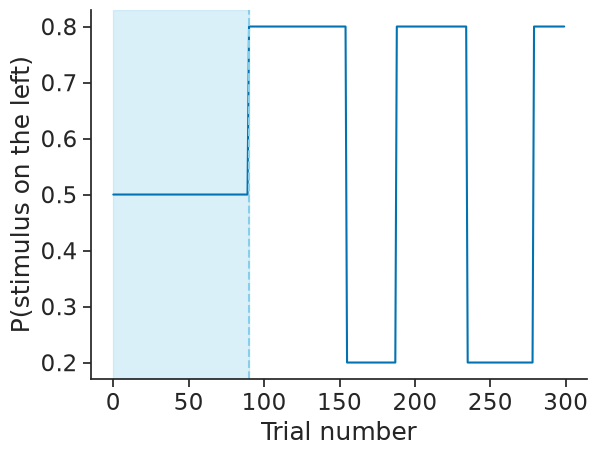

In [6]:

# Plot
plt.plot(trials_sess["probabilityLeft"][:300])
plt.axvspan(0, 90, color="skyblue", alpha=0.3, label="first 90 trials")
plt.axvline(90, color="skyblue", linestyle="--")

plt.ylabel("P(stimulus on the left)")
plt.xlabel("Trial number")
plt.show()

#TODO: add dropdown with original figures.

In Ashwood et al. (2022) <span id="cite1c"></span><a href="#ref1c">[1c]</a>, only sessions with fewer than 10 violations were used. To follow this work, we will now count the number of violations — trials where the animal made no choice (i.e. `choice == 0`) — during the 50-50 trials. For this, we will:
 1) Subset sessions which include 50-50 trials
 2) Exclude sessions with >10 violation trials

<div class="render-user, render-presenter">
Let's do some pandas wrangling to keep only the sessions that have:

- Filter to sessions that went through all testing blocks (in particular all 50-50, 20-80 and 80-20 blocks). 
- Get the initial 50-50 trial block.
- Fewer than 10 invalid trials in that block. 

</div>

In [7]:
# Invalid choice marker
viol_val = 0

# Selecting the sessions as in the Ashwood at al. paper
# Boolean mask selecting sessions with 50-50, 20-80 and 80-20 blocks
has_three_blocks = (
    trials.groupby("session")["probabilityLeft"]
          .agg(lambda s: set(s.unique()) == {0.2, 0.5, 0.8})
)

# Boolean mask selecing sessions with < 10 invalid trials in the 50-50 block
violations = (
    trials.query("probabilityLeft == 0.5")
          .groupby("session")["choice"]
          .agg(lambda s: s.eq(viol_val).sum())
)

valid_sessions = has_three_blocks.index[has_three_blocks & (violations < 10)]

print(f"# of sessions before restrictions {trials['session'].nunique()}")

# Keep only the 50/50 trials from valid sessions (row order preserved by the filter)
df_trials = trials.query("session in @valid_sessions and probabilityLeft == 0.5")

print(f"# of sessions after restrictions {df_trials['session'].nunique()}")

# of sessions before restrictions 73
# of sessions after restrictions 56


## Design matrix

<div class="render-all">
Now, with the valid sessions, we can compute the design matrix. In our case, we are interested in building a design matrix with three predictors: signed contrast, previous choice and win stay lose shift.
</div>


<div class="render-all">


![Design matrix](../../_static/design_matrix_table.svg)


</div>

The first predictor, signed contrast, encodes sensory evidence in 1D. Within this predictor, magnitude reflects strength of evidence and sign encodes direction. The second predictor, previous choice, is a lagged version of current choice, and it reflects serial dependence on decisions. The third predictor, win-stay lose-shift, reflects the interaction between past choice and outcome. If a choice was rewarded on the previous trial, the predictor signals to "stay" (repeat that choice); if it was not rewarded, it signals to "switch" to the other alternative.

Let's go through the process of building the design matrix.

<div class="render-presenter, render-user">

- Extract the columns we need for the design: `choice`, `contrastLeft`, `contrastRight` and `feedbackType` (reward). 

</div>

<div class="render-user render-presenter">
```{code-cell} ipython3
# Select the necessary columns (and reset_index + drop): 
# choice, contrast of stimuli and reward
choices = 
stim_left = 
stim_right = 
rewarded = 
```
</div>

In [8]:
# We can select all the necessary values for the design matrix: 
# choice, contrast of stimuli and reward
choices = df_trials['choice'].values
stim_left = df_trials['contrastLeft'].values
stim_right = df_trials['contrastRight'].values
rewarded = df_trials['feedbackType'].values
session = df_trials['session'].values

For the first predictor: signed contrast.

<div class="render-presenter, render-user">

- Replace `NaN` contrast values with `0` using `np.nan_to_num`.
- Compute the signed contrast (difference between left and right)

</div>

<div class="render-user, render-presenter">
```{code-cell} ipython3
# Replace nans with 0s
stim_left = 
stim_right = 
# Compute the signed contrast (left - right)
signed_contrast = 
print(signed_contrast)
```
</div>

In [9]:
# Replace nans with 0s
stim_left = np.nan_to_num(stim_left, nan=0)
stim_right = np.nan_to_num(stim_right, nan=0)

# Compute the signed contrast
signed_contrast = stim_left - stim_right

# print the design for the first valid session
select_session = df_trials["session"] == valid_sessions[0]
signed_contrast[select_session]

array([ 0.125 ,  0.25  , -1.    , -1.    , -0.25  ,  0.25  ,  0.    ,
        1.    ,  0.25  ,  1.    , -0.0625, -0.0625, -0.25  , -1.    ,
       -0.25  ,  0.    ,  0.25  , -1.    , -0.25  ,  0.25  ,  0.125 ,
        0.0625, -1.    ,  0.125 ,  0.    , -1.    ,  0.25  ,  0.25  ,
       -1.    , -0.25  ,  1.    ,  1.    , -1.    ,  0.    ,  0.0625,
       -0.25  ,  0.    , -1.    , -0.25  , -1.    ,  1.    ,  0.125 ,
        0.0625, -0.0625,  0.0625, -0.25  , -1.    ,  1.    , -0.0625,
        0.125 ,  1.    ,  1.    , -0.25  ,  0.125 ,  0.0625, -1.    ,
       -0.25  ,  0.125 ,  0.125 ,  0.25  ,  0.    , -0.25  ,  0.125 ,
        0.0625, -0.125 ,  1.    , -0.125 , -1.    ,  1.    ,  0.125 ,
        0.25  , -0.25  ,  0.0625,  0.125 ,  0.    , -0.0625, -0.0625,
       -0.125 ,  0.125 , -0.125 , -0.0625, -1.    ,  0.25  ,  1.    ,
        0.125 ,  0.0625,  1.    , -0.25  ,  0.    ,  0.25  ])

<div class="render-presenter, render-user">

- Get the index of the valid trials with `np.flatnonzero`

</div>


<div class="render-user, render-presenter">
```{code-cell} ipython3
valid_choices_idx =
```
</div>

In [10]:
valid_choices_idx = np.flatnonzero(choices != viol_val)

With those two elements we can compute our design matrix for this session, we can do this using nemos basis objects: 


- ```HistoryConv``` includes the past values of a sample as predictors (raw history). You choose how far back to go; here we only need one trial in the past. We use this to create the previous-choice predictor.

- ```IdentityEval``` uses the samples themselves as predictors; its purpose is simply to wrap them as a NeMoS object. We use this for the stimuli predictor. 

It is very easy to declare our basis objects:

<div class="render-user, render-presenter">
Let's use the `basis` module from  NeMoS to define the design matrix. 

What we need is:

- A `HistoryConv` basis to capture the choice history. We need a `window_size=1` to include the previous 1 choice as predictor.

</div>

<div class="render-user, render-presenter">
```{code-cell} ipython3
# Prev history with history of 1
prev_choice_basis = nmo.basis.HistoryConv(1)
```
</div>

In [11]:
# Prev history with history of 1
prev_choice_basis = nmo.basis.HistoryConv(1)

<div class="render-user, render-presenter">

- A `IdentityEval` basis to include the signed contrast as is. This may seem pointless, but will allow us to add the basis and form the full design matrix in one go.

</div>

<div class="render-user, render-presenter">
```{code-cell} ipython3
# Identity basis for stimuli
stimuli_basis = nmo.basis.IdentityEval()
```
</div>

In [12]:
# Identity basis for stimuli
stimuli_basis = nmo.basis.IdentityEval()

However, we are still missing one predictor: win-stay lose-shift. This is an interaction of previous choice with previous reward. To capture interaction between variables, we can use a [multiplicative basis object](https://nemos.readthedocs.io/en/latest/background/basis/plot_02_ND_basis_function.html#n-dimensional-basis), which takes the outer product of the elements that compose it.

<div class="render-user, render-presenter">


- Win-stay lose-shift is the product of previous choice and previous reward, $WSLS_t = c_{t-1} \cdot r_{t-1}$.
- We can use [basis multiplication](https://nemos.readthedocs.io/en/latest/background/basis/plot_02_ND_basis_function.html#n-dimensional-basis) to construct that predictor. 

</div>

<div class="render-user, render-presenter">
```{code-cell} ipython3
# Create lagged reward basis
prev_reward_basis = 
# Multiply lagged reward basis with the lagged choice basis
wsls_basis = 
```
</div>

In [13]:
# Create lagged reward basis
prev_reward_basis = nmo.basis.HistoryConv(1)

# Multiply lagged reward basis with the lagged choice basis
wsls_basis = prev_choice_basis*prev_reward_basis

Now that we have all our bases, we can combine them into an additive basis and apply the transformation to the input data using ```compute_features```. This method is a high-level interface for transforming input data with the basis functions. 

Even though we need just a few lines of code, there is a lot going on. Here's a breakdown of what is happening:
1. We will create an additive basis ```basis_object``` with our bases ```stimuli_basis```, ```wsls_basis``` and ```prev_choice_basis```. 
2. ```wsls_basis``` is a multiplicative basis that takes two inputs.
3. We will compute the features for our ```basis_object``` using ```compute_features```. Since the bases in our composite basis take a total of 4 inputs (```stimuli_basis``` takes 1 input, ```wsls_basis``` takes 2 inputs and ```prev_choice_basis``` takes 1 input), we need to pass 4 features to ```compute_features```.


<div class="render-user, render-presenter">


- Use [basis addition](https://nemos.readthedocs.io/en/latest/background/basis/plot_02_ND_basis_function.html#additive-basis-object) to define a basis which concatenates predictor.
- Create the design matrix by calling `compute_features`. Select the valid trials by applying the `valid_choices_idx` boolean mask.

</div>

<div class="render-presenter, render-user">
```{code-cell} ipython3
# Create an additive basis using our three components
basis_object =
# Call compute features to get the raw model design
X_unnormalized = 
X_unnormalized[:5,:]
```
</div>

In [14]:
# Create an additive basis using our three components
basis_object = (
    stimuli_basis +      # will process one input
    wsls_basis +         # will process two inputs (choice & reward)
    prev_choice_basis    # will process one input
)

# Compute features
X_unnormalized = basis_object.compute_features(
    # input 1 : processed with stimuli_basis
    signed_contrast[valid_choices_idx],
    # input 2 : wsls input 1: choice
    choices[valid_choices_idx],
    # input 3 : wsls input 2: reward
    rewarded[valid_choices_idx],
    # input 4 : processed with prev_choice
    choices[valid_choices_idx],
)

X_unnormalized[:5,:]

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


array([[ 1.   ,    nan,    nan],
       [-1.   ,  1.   ,  1.   ],
       [-0.25 , -1.   , -1.   ],
       [ 0.   , -1.   , -1.   ],
       [-0.125, -1.   , -1.   ]])

And that's it! We have our unnormalized design matrix with signed contrast, win-stay lose-shift and previous choice as predictors.

As a last step, we normalize the signed-contrast predictor.

<div class="render-presenter, render-user">
- Z-score the contrast values.
</div>

<div class="render-user, render-presenter">
```{code-cell} ipython3
from scipy.stats import zscore
# Copy the array (we'll need the un-normalized later)
X = np.copy(X_unnormalized)
# Apply z-scoring
X[:, 0] = 
```
</div>

In [15]:
# Copy the array (we'll need the un-normalized later)
X = np.copy(X_unnormalized)

We z-score only the signed-contrast predictor (column 0), leaving the previous-choice and WSLS columns untouched since they are already on a unit scale. See the dropdown below for why this matters.

In [16]:
from scipy.stats import zscore
# Apply z-scoring
X[:, 0] = zscore(X[:, 0])

:::{admonition} Why do we normalize our stimuli predictor?
:class: question render-all
:class: dropdown

When fitting a GLM-HMM, we are fitting a separate weight for each feature. However, if the features are on different numerical scales for reasons that are not related to the actual influence of each predictor, that renders the weights incomparable. Here we have three predictors:  
- (1) Previous choice and (2) WSLS are always exactly −1 or +1. Their values are discrete and bounded, and they already share the same scale.
- (3) Stimuli contrast is continuous. While it can reach −1 or +1 (full contrast), this value rarely occurs. 

Because the contrast values are typically much smaller in magnitude than ±1, the model compensates by assigning them a larger weight to match the output scale — purely because the values are numerically smaller. In practice, this is an artifact of scale that does not reflect the true influence of the predictor.

By normalizing, we rescale the predictor to have mean 0 and standard deviation 1. Previous choice and WSLS are already on a unit scale by construction — their values are symmetric around zero and their spread is naturally 1. This is why we only normalize signed contrast.
:::

and see our design matrix.

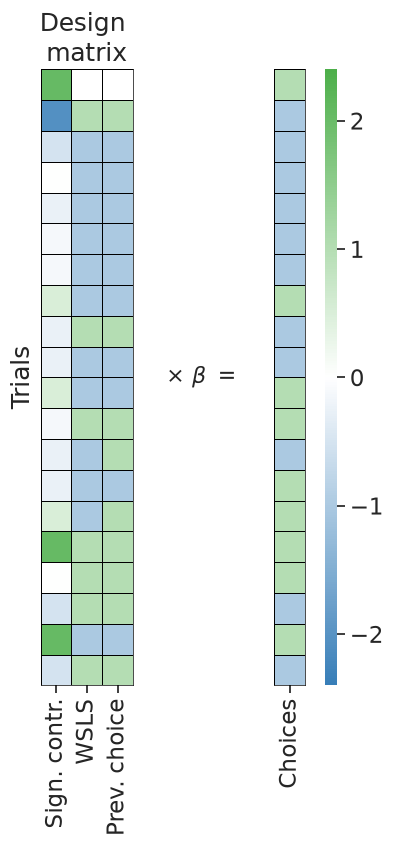

In [17]:
# Plot an heatmap showing the model design
workshop_utils.plot_design_matrix(X, choices, valid_choices_idx);

## Model fitting

We are going to fit a Bernoulli GLM-HMM to model binary choices. For this reason, we must convert choices from the original $\{-1, 1\}$ encoding to $\{0, 1\}$.

<div class="render-presenter, render-user">
- For a Bernoulli GLM-HMM, observations must take values of 0 or 1.
- Convert choices to 0s and 1s. 1: Left and 0: Right. You can use `np.where`.
</div>

<div class="render-user, render-presenter">
```{code-cell} ipython3
choices = 
```
</div>

In [18]:
choices = np.where(choices == -1, 0, choices)

Importantly, we don't fit all 3000 trials as one continuous block. The data come as separate sessions of 100–300 trials, and we fit the model on all of them together. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute all sessions as if they were one. 


In NeMoS we have two ways of indicating the beginning of a new session. You can use a Pynapple Tsd or TsdFrame to demarcate sessions, in which case session demarcations are inherited from the pynapple objects. Alternatively, when using a design matrix and a choice vector that are Numpy objects, it is necessary to pass a session indicator. This can be:
- a boolean array or integer array of 1s and 0s indicating session starts, shape ``(n_samples,)``
- an integer array of indices marking session starts, shape ``(n_sessions,)``
- a pynapple.IntervalSet marking session epochs (requires either X or y to be a pynapple Tsd or TsdFrame to get timestamps)

<div class="render-presenter, render-user">
- Create a vector containing the indices of each session start.
</div>

<div class="render-presenter, render-user">
```{code-cell} ipython3
# Mark where session changes
new_sess_mouse = 
```
</div>

In [19]:
# Mark where session changes
new_sess_mouse = np.flatnonzero(session[1:] != session[:-1]) + 1

:::{admonition} How does this one-liner find the session starts?
:class: note dropdown render-all

`session` holds one session id per trial. Comparing `session[1:]` (every trial but the first) with `session[:-1]` (every trial but the last) yields a boolean array that is `True` wherever a trial's session id differs from the previous trial's — that is, exactly at the session boundaries. `np.flatnonzero` returns the indices where this is `True`, and we add `1` because the comparison is shifted by one (position `i` in the comparison corresponds to trial `i+1`). The result is the array of indices at which a new session begins.
:::

Let's initialize the ```GLMHMM``` object. The only required parameter is the number of states. Ashwood et al. (2022) <span id="cite1d"></span><a href="#ref1d">[1d]</a> found that most mice used 3 decision-making states when performing this task. Following that work, we will initialize our ```GLMHMM``` object with 3 states.

The likelihood of a GLM-HMM is non-convex, so the EM algorithm used to fit it can converge to different local optima depending on the starting parameters. NeMoS initializes the model for you: by default, the per-state intercepts are set to match the empirical choice probability, and the GLM coefficients are drawn from a Gaussian centered at zero with a small standard deviation. The `seed` argument controls this random draw, so in practice you should refit the model with several seeds and keep the solution with the highest log-likelihood.


<div class="render-presenter, render-user">
- Initialize the `GLMHMM` object with 3 states and `regularizer="Ridge"`.
- Set seed for trying different initial parameters (`jax.random.PRNGKey(number)`).
- By default, the intercept is set to match the empirical choice probability, and the coefficients are set as random gaussian centered at zero with small standard deviation.
</div>


<div class="render-presenter, render-user">
```{code-cell} ipython3
n_states = 3
model = nmo.glm_hmm.GLMHMM(
model
```
</div>

In [20]:
n_states = 3

model = nmo.glm_hmm.GLMHMM(
    n_states,
    regularizer="Ridge",
    # change this to try multiple init
    seed=jax.random.PRNGKey(12), 
)

model

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...x7f69676f4680>
,regularizer,Ridge()
,solver_name,'LBFGS'
,solver_kwargs,{}
,seed,"Array([ 0, 12], dtype=uint32)"
,hmm_initialization_funcs,"{'initial_proba_init': <function uni...x7f69641edb20>, 'initial_proba_init_custom': False, 'initial_proba_init_kwargs': {}, 'transition_proba_init': <function sti...x7f69641ed760>, ...}"
,model_initialization_funcs,"{'glm_params_init': <function ran...x7f691d394220>, 'glm_params_init_custom': False, 'glm_params_init_kwargs': {}, 'scale_init': <function con...x7f691d3947c0>, ...}"
,regularizer_strength,1.0
,dirichlet_initial_proba,None


Once we created our object, we can fit our model. The fit function takes two mandatory arguments: the design matrix ```X``` we created above and the ```choices```. Additionally, we will also include ```new_sess_mouse```, the new session indicator.


<div class="render-presenter, render-user">

- Fit the model providing the `new_sess_mouse` markers as the `session_starts` argument of `model.fit`.

</div>

In [21]:
model.fit(
    X, 
    choices,
    session_starts=new_sess_mouse
)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...x7f69676f4680>
,regularizer,Ridge()
,solver_name,'LBFGS'
,solver_kwargs,{}
,seed,"Array([ 0, 12], dtype=uint32)"
,hmm_initialization_funcs,"{'initial_proba_init': <function uni...x7f69641edb20>, 'initial_proba_init_custom': False, 'initial_proba_init_kwargs': {}, 'transition_proba_init': <function sti...x7f69641ed760>, ...}"
,model_initialization_funcs,"{'glm_params_init': <function ran...x7f691d394220>, 'glm_params_init_custom': False, 'glm_params_init_kwargs': {}, 'scale_init': <function con...x7f691d3947c0>, ...}"
,regularizer_strength,1.0
,dirichlet_initial_proba,None


That's all it takes!


## Results interpretation

### How to visualize the fitted parameters

<div class="render-presenter, render-user">

Latent state labels are arbitrary. Below we permute those labels to match that of the reference paper.

</div>

In [22]:
permutation = jnp.array([1, 2, 0])
model.coef_ = model.coef_[:, permutation]
model.intercept_ = model.intercept_[permutation]
model.transition_prob_ = model.transition_prob_[permutation][:, permutation]

<div class="render-all">

The GLM coefficients and intercept, and the HMM initial and transition probabilities are stored in the following attributes:

- `model.coef_`
- `model.intercept_`
- `model.initial_prob_`
- `model.transition_prob_`

Let's print them
</div>

In [23]:
print("GLM parameters\n==============")
print(f"glm weights:\n{model.coef_}\n")
print(f"intercept:\n{model.intercept_}")

print("\n\nHMM parameters\n==============")
print(f"transition matrix \n {model.transition_prob_}\n")
print(f"initial probabilities \n {model.initial_prob_}")

GLM parameters
glm weights:
[[ 6.09399091  1.5439169   1.59525073]
 [ 0.09836777  0.28091053  0.32646422]
 [ 0.11747475 -0.31333297  0.41791669]]

intercept:
[ 0.02502527  2.74184029 -2.19821672]


HMM parameters
transition matrix 
 [[0.9821805  0.01077484 0.00704465]
 [0.03767531 0.95278875 0.00953594]
 [0.0406587  0.00323314 0.95610817]]

initial probabilities 
 [0.23419059 0.64974029 0.11606913]


<div class="render-all">
Let's see what type of information we can gather.
</div>

### Interpreting the GLM weights

<div class="render-all">
We can plot the GLM weights obtained for our 3-state model.
</div>

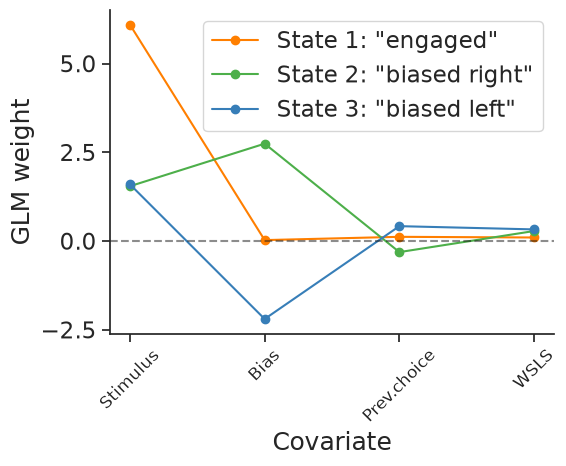

In [24]:
workshop_utils.plot_glm_weights(model);

We can see that the coefficients on state 1 have a large weight on the stimulus and low weight on the other predictors. Conversely, in states 2 and 3, the stimulus coefficient is comparatively lower. State 2 has a large positive weight on bias, while State 3 has a large negative weight on bias. Since the sign of our predictors indicates the side of evidence (>0 : left; <0 : right, see the table of variables in section 01) and their magnitude indicates the strength of such evidence, State 2 coefficients suggest a large bias towards leftward choice, while State 3 coefficients suggest a large bias to a rightward choice. All states have similarly low coefficients for prev. choice and wsls, with State 1 showing the smallest of them. 

As a reminder, the task required indicating whether the stimulus was on the right or the left of the screen, using the stimulus contrast. The optimal strategy is therefore to rely on stimulus contrast as much as possible, rather than on bias, previous choice, or WSLS.

<div class="render-presenter, render-user">

- State 1 have larger weight on the stimulus and low on the other predictors.
- The bias weight is larger in absolute value for state 2 and 3, but of opposite sign. (>0 : left; <0 : right)

</div>

### Interpreting the transition matrix
We can also see the fitted transition matrix for our three-state model. This describes the transition probabilities among the different states, each corresponding to a different decision-making strategy. Large entries in the diagonal indicate a high probability of remaining in the same state for multiple trials in a row.

<div class="render-presenter, render-user">

- Let's visualize the transition matrix. The utility function below plots the heatmap.

</div>

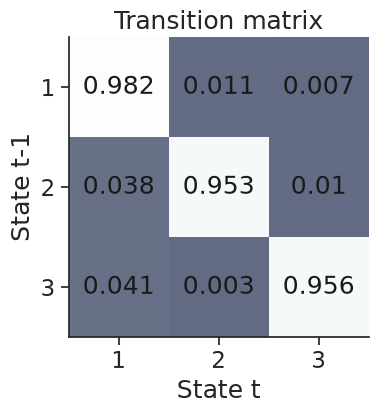

In [25]:
workshop_utils.plot_transition_matrix(model);

### Using ```smooth_proba``` to visualize and interpret posterior state probabilities
To better understand the temporal structure of decision making behavior, we can compute the probability of being in each state at each trial, conditioned on the entire observed sequence. For this, we can use ```smooth_proba```. This method uses the forward-backward algorithm to incorporate information from past and future observations. It answers the question: "Given all observations, what is the probability that the system was in state $k$ at time $t$?"

```smooth_proba``` takes two arguments: a design matrix `X` and `y` the observed choices. The output is either a ```TsdFrame``` or an array of  posterior probabilities, shape ``(n_time_points, n_states)``. Each row sums to 1 and represents the probability distribution over states at that time point.


<div class="render-presenter, render-user">

- Call `smooth_proba` to compute the smoothing posterior probabilities of the latent states.
- Remember to provide the `session_starts=new_sess_mouse` parameter to mark the beginning of each session.
- Filter non-nan entries and check that the posterior sums to 1 over the states.

</div>

<div class="render-presenter, render-user">
```{code-cell} ipython3
# Compute smooth_proba
posteriors = 
print(f"First five posteriors \n{posteriors[:5]} \n")
# Each (valid) posterior row sums to 1
valid = ~np.isnan(posteriors).any(axis=1)
print(
    "Does the posterior sum to one?", 
    np.allclose( , 1)
)
```
</div>

In [26]:
# Compute smooth_proba
posteriors = model.smooth_proba(
    X, 
    choices,
    session_starts=new_sess_mouse
)
print(f"First five posteriors \n{posteriors[:5]} \n")

# Each (valid) posterior row sums to 1
valid = ~np.isnan(posteriors).any(axis=1)
print(
    "Does the posterior sum to one?", 
    np.allclose(posteriors[valid].sum(axis=1), 1)
)

First five posteriors 
[[           nan            nan            nan]
 [7.53779332e-01 6.19965623e-02 1.84224106e-01]
 [8.15356738e-01 7.34994887e-03 1.77293313e-01]
 [8.34498446e-01 7.72118170e-04 1.64729436e-01]
 [8.60963299e-01 1.23540946e-04 1.38913160e-01]] 

Does the posterior sum to one? True


The first trial of each session is `NaN`: the posterior depends on the transition from the previous trial's state, which doesn't exist at a session start. Hence we mask out the NaNs before checking that the rows sum to one.

<div class="render-all">
Let's plot the first 90 trials, corresponding to the first session.
</div>

<div class="render-presenter, render-user">

- Use `color=["#ff7f00", "#4daf4a", "#377eb8"]` for a matching color code.

</div>

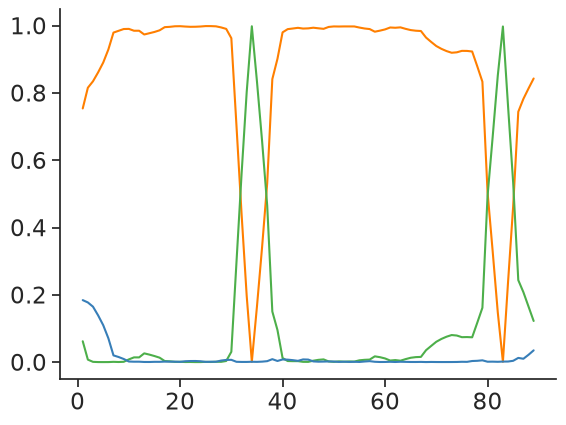

In [27]:
colors = ["#ff7f00", "#4daf4a", "#377eb8"]
for i, c in enumerate(colors):
    plt.plot(posteriors[:90, i], color=c)

<div class="render-all">
Let's now use the utility function to plot the three sessions shown in Fig. 3a of <span id="cite1e"></span><a href="#ref1e">[1e]</a>.
</div>

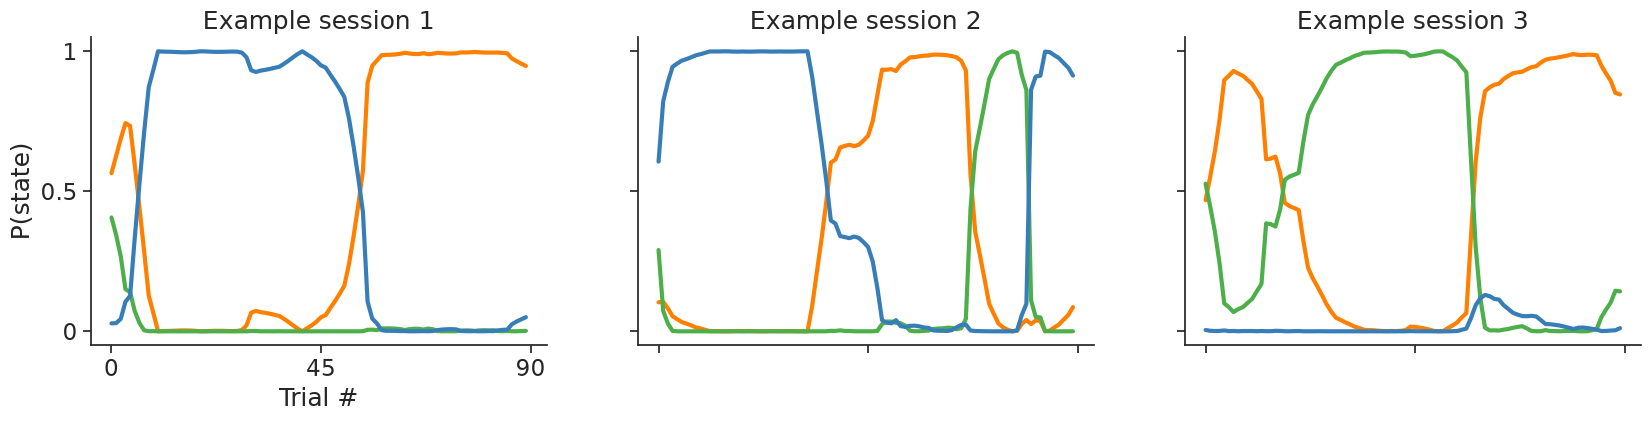

In [28]:
workshop_utils.plot_posteriors(posteriors, session);

In these sessions, the posterior over latent states can be tracked at each trial, revealing strong confidence in state assignments and extended periods where a single state persists across consecutive trials. 



### Understanding mouse behavior in different states


We may also want to quantify state fractional occupancies (i.e. what proportion of the trials a given animal spent in each state) and the mouse's accuracy in each state (i.e. how often it chose the correct side). For this, we need the inferred sequence of states, this can be obtained using the [Viterbi algorithm](https://en.wikipedia.org/wiki/Viterbi_algorithm) that you can run by calling the  ```decode_state``` method.

This method finds the single most likely sequence of hidden states that best explains the observed data: the state sequence that maximizes the joint probability of states and observations. It takes three mandatory parameters, a matrix of predictors `X` of shape `(n_timepoints,n_features)`, a `np.array` or `nap.Tsd` of observations of shape `(n_time_points,)`, and the format of the returned states, either in one-hot encoding format or as an array of shape `(n_time_points,)` containing the decoded state at each timepoint.

<div class="render-presenter, render-user">

- Get the most likely sequence of states given the observation by calling `decode_state`, which runs the Viterbi (also known as max-sum) algorithm.
- Remember to provide the `session_starts=new_sess_mouse`

</div>

<div class="render-presenter, render-user">
```{code-cell} ipython3
# get output of viterbi in one-hot encoding
decoded_states = 
decoded_states
```
</div>

In [29]:
# get output of viterbi in one-hot encoding
decoded_states = model.decode_state(
    X,
    choices,
    session_starts=new_sess_mouse,
    state_format = "one-hot"
)
decoded_states

Array([[nan, nan, nan],
       [ 1.,  0.,  0.],
       [ 1.,  0.,  0.],
       ...,
       [ 0.,  0.,  1.],
       [ 0.,  0.,  1.],
       [ 0.,  0.,  1.]], dtype=float64, weak_type=True)

From this we can compute the fractional occupancy, while correctly filtering out the NaNs.

<div class="render-presenter, render-user">

- Compute the fractional occupancy for each state.
- Remember that the decoded states may contain NaNs.

</div>

In [30]:
# calculate occupancy
valid = np.all(~np.isnan(decoded_states), axis=1)
frac_occupancy_viterbi= np.nansum(decoded_states, axis=0) / valid.sum()
print(f"Fraction of occupancy {frac_occupancy_viterbi} \n")

Fraction of occupancy [0.70569557 0.15399881 0.14030562] 



Now we can compute the mouse's overall accuracy.

<div class="render-presenter, render-user">

- Compute the accuracy:
  - Mask out the 0 contrast stimuli (because there is no correct answer in that case)
  - `choice==0`: right choice, `choice==1`: left choice.
  - `signed_contrast < 0`: left stimulus presented, `signed_contrast > 0`: right stimulus presented.
  - Use convention above to get the accuracy.

</div>

<div class="render-presenter, render-user">
```{code-cell} ipython3
# mask out the 0 contrast stimuli
mask =
# compute stimulus and chocie side applying the mask
stim_side =
# compute the accuracy
total_accuracy = 
# store in an array of dim 4
accuracies_to_plot_viterbi = np.zeros(4)
accuracies_to_plot_viterbi[0] = total_accuracy
```
</div>

In [31]:
# mask out the 0 contrast stimuli
mask = signed_contrast != 0

# compute stimulus and chocie side
stim_side = signed_contrast > 0

# get the correct choices boolean
correct_choices = choices == stim_side

# compute the total accuracy applying the mask
total_accuracy = np.mean(correct_choices[mask])

# store in an array of dim 4
accuracies_to_plot_viterbi = np.zeros(4)
accuracies_to_plot_viterbi[0] = total_accuracy

And then we can use our output of ```decode_state``` to segment the trials into the estimated states and compute the accuracy within each state.


<div class="render-presenter, render-user">

- Loop over the states and apply the same calculation to get the accuracy per state.

</div>

<div class="render-presenter, render-user">
```{code-cell} ipython3
accuracy_per_state = np.zeros(n_states)
for s in range(n_states):
  in_state =
  accuracy_per_state[s] =
accuracies_to_plot_viterbi[1:] = accuracy_per_state
```
</div>

In [32]:
accuracy_per_state = np.zeros(n_states)
for s in range(n_states):
  in_state = (decoded_states[:, s] == 1) & mask
  accuracy_per_state[s] = correct_choices[in_state].mean()

accuracies_to_plot_viterbi[1:] = accuracy_per_state

And we can plot this :)

<div class="render-presenter, render-user">

- Plot the output.

</div>

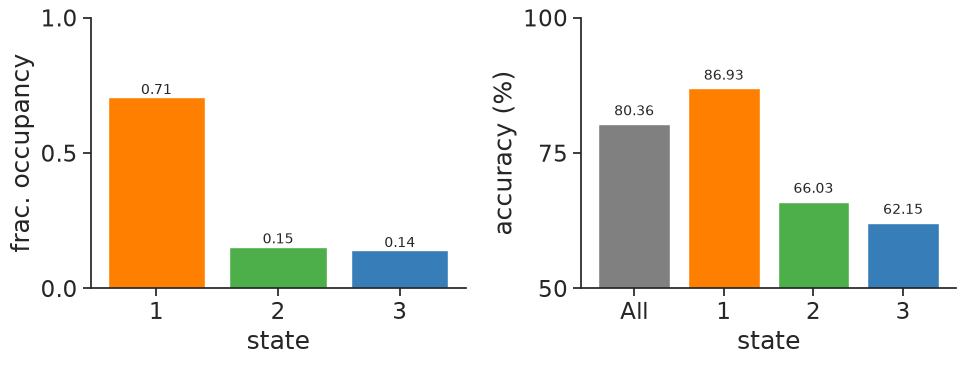

In [33]:
workshop_utils.plot_accuracy_and_occupancy(
    frac_occupancy_viterbi, 
    accuracies_to_plot_viterbi
);

According to state occupancy derived with the Viterbi algorithm, this mouse spent the majority of the trials (70%) in the engaged state and a lesser portion of trials in the other two states (30%). We can see that even though this mouse had an overall accuracy of 80.36%, it achieved a higher accuracy of 87.04% in the "engaged" state compared to 66.03% and 63.03% in the "bias left" and "bias right", respectively.

## Additional Exercises

<div class="render-all">

- Compute the accuracy by segmenting the trials according to the smoothing posterior, as was done in the original paper. Restrict the analysis to trials in which the model is highly confident about the state assignment — for example, keep only trials where the smoothing posterior assigns a state more than 90% probability. Compare the results with the procedure shown here.

- Try varying the regularization strength and see what happens to the learned GLM parameters. Do the results still hold as you decrease the regularization strength? What happens to the model predictions? Try cross-validating the regularization strength and see how the optimal regularizer compares with the one used here (the nemos default, which is 1).

- What happens when you add or remove states? Can you cross-validate the number of states? Which number seems optimal according to your cross-validation procedure? Can you get a better cross-validated likelihood with more states?

</div>



## Additional resources

<div class="render-all">

- [Bishop (2006) Chapter 13 "Sequential Data"](https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf): Specially section 13.2, "Hidden Markov Models", provides an overview of MLE for HMMs, the forward-backward algorithm and the viterbi algorithm.
- [Zoe Ashwood's SSM tutorial on GLM-HMMs](https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb): this educational notebook explains GLM-HMMs and fitting with MLE and MAP.
- [GLM-HMMs blogpost by Camila Ucheoma](https://anneurai.net/2024/01/26/a-glm-hmm-deep-dive/): this blogpost provides a summary of Ashwood et al. (2022) work and a brief explanation of GLM-HMMs

</div>

## References

<div class="render-all">

<a id="ref1a"><a href="#cite1a">[1a]</a> <a id="ref1b"><a href="#cite1b">[1b]</a> <a id="ref1c"><a href="#cite1c">[1c]</a> <a id="ref1d"><a href="#cite1d">[1d]</a> <a id="ref1e"><a href="#cite1e">[1e]</a> [Ashwood, Z. C., Roy, N. A., Stone, I. R., Laboratory, I. B., Urai, A. E., Churchland, A. K., Pouget, A., & Pillow, J. W. (2022). Mice alternate between discrete strategies during perceptual decision-making. Nature Neuroscience, 25(2), 201–212.](https://doi.org/10.1038/s41593-021-01007-z)

<a id="ref2a"><a href="#cite2a">[2a]</a> <a id="ref2b"><a href="#cite2b">[2b]</a> <a id="ref2c"><a href="#cite2c">[2c]</a> [The International Brain Laboratory, Aguillon-Rodriguez, V., Angelaki, D., Bayer, H., Bonacchi, N., Carandini, M., Cazettes, F., Chapuis, G., Churchland, A. K., Dan, Y., Dewitt, E., Faulkner, M., Forrest, H., Haetzel, L., Häusser, M., Hofer, S. B., Hu, F., Khanal, A., Krasniak, C., … Zador, A. M. (2021). Standardized and reproducible measurement of decision-making in mice. eLife, 10, e63711.](https://doi.org/10.7554/eLife.63711)

<a id="ref3a"><a href="#cite3a">[3a]</a> <a id="ref3b"><a href="#cite3b">[3b]</a> <a id="ref3c"><a href="#cite3c">[3c]</a> [Burgess, C. P., Lak, A., Steinmetz, N. A., Zatka-Haas, P., Bai Reddy, C., Jacobs, E. A. K., Linden, J. F., Paton, J. J., Ranson, A., Schröder, S., Soares, S., Wells, M. J., Wool, L. E., Harris, K. D., & Carandini, M. (2017). High-Yield Methods for Accurate Two-Alternative Visual Psychophysics in Head-Fixed Mice. Cell Reports, 20(10), 2513–2524.](https://doi.org/10.1016/j.celrep.2017.08.047)

<a id="ref4"><a href="#cite4">[4]</a> [Escola, S., Fontanini, A., Katz, D., & Paninski, L. (2011). Hidden Markov models for the stimulus-response relationships of multistate neural systems. Neural Computation, 23(5), 1071–1132.](https://doi.org/10.1162/NECO_a_00118)

</div>